In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from statsmodels.tsa.stattools import adfuller

In [2]:
df = pd.read_csv("../data/raw/BrentOilPrices.csv")

In [3]:
df["Date"] = pd.to_datetime(df["Date"])

C:\Users\User\AppData\Local\Temp\ipykernel_12440\936118274.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df["Date"] = pd.to_datetime(df["Date"])


In [4]:
df.head()

,Date,Price
0,1987-05-20,18.63
1,1987-05-21,18.45
2,1987-05-22,18.55
3,1987-05-25,18.60
4,1987-05-26,18.63


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 9011 entries, 0 to 9010
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   Date    9011 non-null   datetime64[us]
 1   Price   9011 non-null   float64       
dtypes: datetime64[us](1), float64(1)
memory usage: 140.9 KB


In [6]:
df.describe()

,Date,Price
count,9011,9011.000000
mean,2005-02-10 23:46:53.760958,48.420782
min,1987-05-20 00:00:00,9.100000
25%,1996-03-20 12:00:00,19.050000
50%,2005-02-02 00:00:00,38.570000
75%,2014-01-09 12:00:00,70.090000
max,2022-11-14 00:00:00,143.950000
std,NaN,32.860110


In [7]:
df.isnull().sum()

Date     0
Price    0
dtype: int64

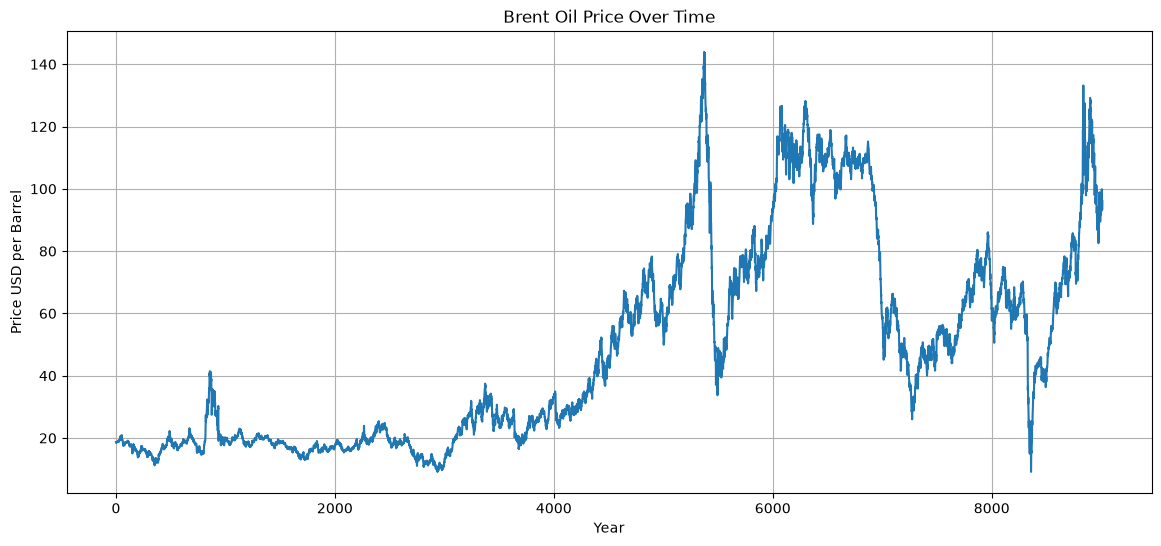

In [8]:
plt.figure(figsize=(14,6))

plt.plot(df.index, df["Price"])

plt.title("Brent Oil Price Over Time")
plt.xlabel("Year")
plt.ylabel("Price USD per Barrel")

plt.grid()

plt.show()

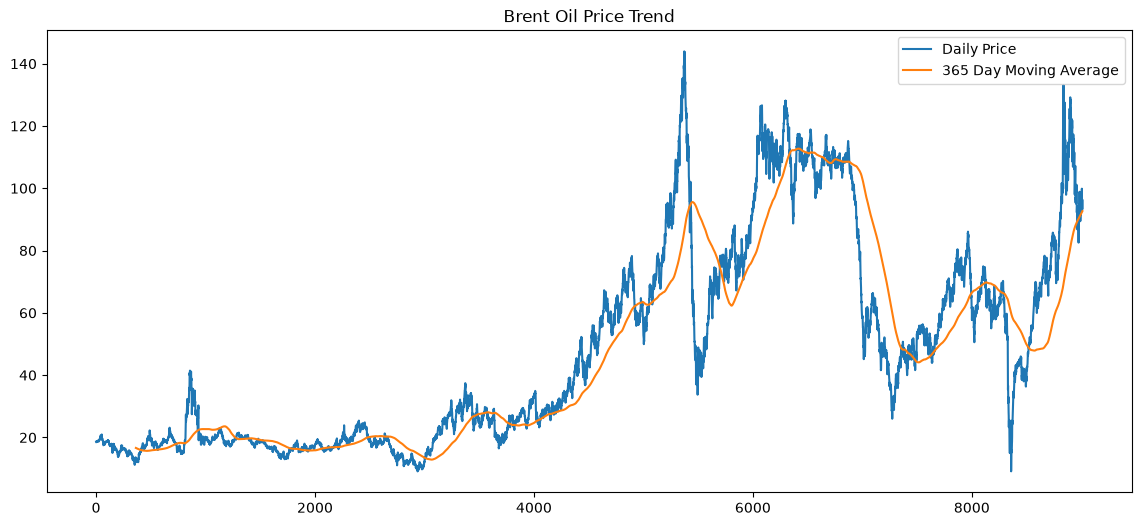

In [9]:
df["Rolling_Mean_365"] = df["Price"].rolling(365).mean()


plt.figure(figsize=(14,6))

plt.plot(df["Price"], label="Daily Price")

plt.plot(df["Rolling_Mean_365"], 
         label="365 Day Moving Average")

plt.title("Brent Oil Price Trend")

plt.legend()

plt.show()

In [10]:
df["Log_Returns"] = np.log(df["Price"] / df["Price"].shift(1))

df.head()

,Date,Price,Rolling_Mean_365,Log_Returns
0,1987-05-20,18.63,NaN,NaN
1,1987-05-21,18.45,NaN,-0.009709
2,1987-05-22,18.55,NaN,0.005405
3,1987-05-25,18.60,NaN,0.002692
4,1987-05-26,18.63,NaN,0.001612


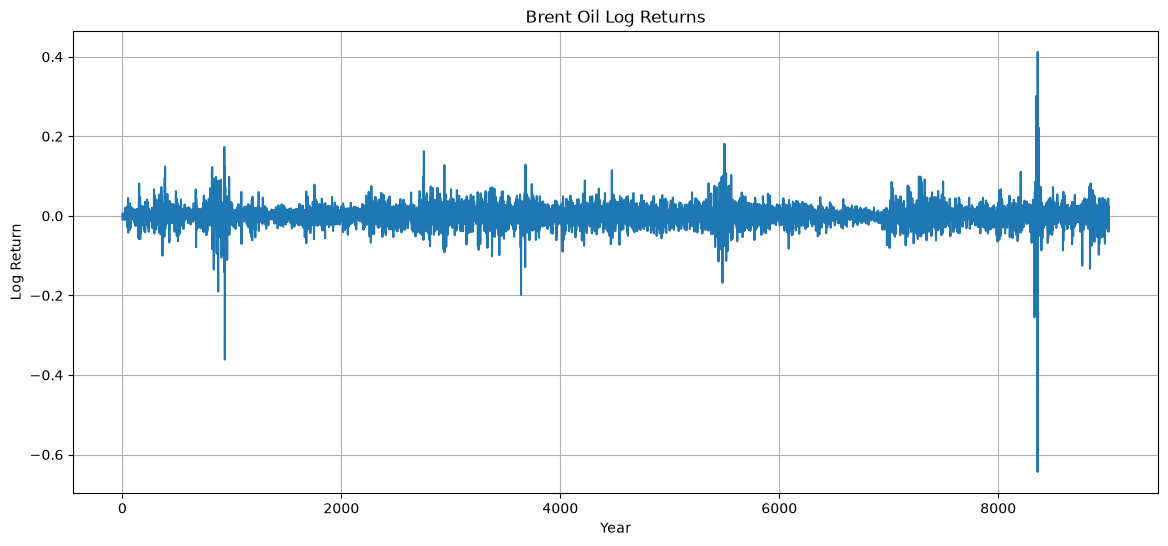

In [11]:
plt.figure(figsize=(14,6))

plt.plot(df["Log_Returns"])

plt.title("Brent Oil Log Returns")

plt.xlabel("Year")

plt.ylabel("Log Return")

plt.grid()

plt.show()

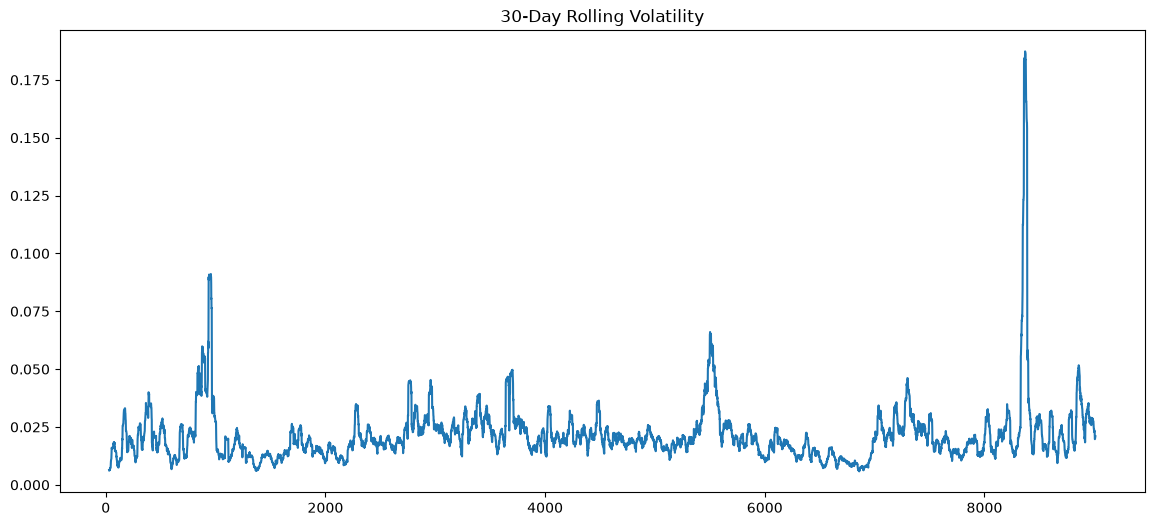

In [12]:
df["Volatility"] = df["Log_Returns"].rolling(30).std()


plt.figure(figsize=(14,6))

plt.plot(df["Volatility"])

plt.title("30-Day Rolling Volatility")

plt.show()

In [13]:
result = adfuller(df["Log_Returns"].dropna())


print("ADF Statistic:", result[0])
print("p-value:", result[1])

ADF Statistic: -16.42711349448583
p-value: 2.498580161143246e-29


In [14]:
import pandas as pd

events = {
    "Date": [
        "1990-08-02",
        "1991-01-17",
        "1997-07-02",
        "2001-09-11",
        "2003-03-20",
        "2008-09-15",
        "2011-01-01",
        "2014-11-27",
        "2016-11-30",
        "2020-03-09",
        "2020-03-11",
        "2022-02-24"
    ],

    "Event": [
        "Iraq invasion of Kuwait",
        "Gulf War begins",
        "Asian Financial Crisis",
        "September 11 attacks",
        "Iraq War",
        "Global Financial Crisis",
        "Arab Spring",
        "OPEC maintains production levels",
        "OPEC production cut agreement",
        "Saudi-Russia oil price war",
        "COVID-19 pandemic declaration",
        "Russia invasion of Ukraine"
    ],

    "Category": [
        "Conflict",
        "Conflict",
        "Economic",
        "Geopolitical",
        "Conflict",
        "Economic",
        "Political",
        "OPEC",
        "OPEC",
        "Market",
        "Economic",
        "Conflict"
    ]
}


events_df = pd.DataFrame(events)

events_df["Description"] = [
    "Iraq invaded Kuwait, creating uncertainty in global oil supply.",
    "Military operations affected Middle East oil markets.",
    "Financial crisis reduced economic growth expectations.",
    "Global geopolitical uncertainty increased.",
    "War increased concerns about oil supply.",
    "Financial crisis reduced global oil demand.",
    "Political instability affected oil-producing regions.",
    "OPEC maintained production levels causing price pressure.",
    "OPEC agreed to reduce production.",
    "Oil price war caused a sharp market decline.",
    "COVID-19 reduced transportation and oil demand.",
    "War increased global energy supply uncertainty."
]


events_df.to_csv(
    "../data/raw/events.csv",
    index=False
)

events_df.head()

,Date,Event,Category,Description
0,1990-08-02,Iraq invasion of Kuwait,Conflict,"Iraq invaded Kuwait, creating uncertainty in g..."
1,1991-01-17,Gulf War begins,Conflict,Military operations affected Middle East oil m...
2,1997-07-02,Asian Financial Crisis,Economic,Financial crisis reduced economic growth expec...
3,2001-09-11,September 11 attacks,Geopolitical,Global geopolitical uncertainty increased.
4,2003-03-20,Iraq War,Conflict,War increased concerns about oil supply.
